In [2]:
import numpy as np
import io

def load_line_fit_parameters(filename):
    B0_fit = None
    B0_err = None
    harmonic_lines = []
    with open(filename, "r") as f:
        for line in f:
            stripped = line.strip()
            if not stripped or stripped.startswith("#"):
                continue
            if B0_fit is None:
                vals = np.fromstring(stripped, sep=" ")
                B0_fit, B0_err = vals[0], vals[1]
            else:
                harmonic_lines.append(stripped)
    harmonics = np.loadtxt(io.StringIO("\n".join(harmonic_lines)))
    if harmonics.ndim == 1:
        harmonics = harmonics[None, :]
    freqs = harmonics[:, 0]
    A_vals = harmonics[:, 1]
    A_errs = harmonics[:, 2]
    phi_vals = harmonics[:, 3]
    phi_errs = harmonics[:, 4]
    return B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs

def _get_line_params(param_file, B0, A60, phi60, A180, phi180):
    if param_file is not None:
        B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs = load_line_fit_parameters(param_file)
        return B0_fit, freqs, A_vals, phi_vals
    freqs = np.array([60.0, 180.0], dtype=float)
    A_vals = np.array([A60, A180], dtype=float)
    phi_vals = np.array([phi60, phi180], dtype=float)
    return B0, freqs, A_vals, phi_vals
# B0 = 0.3350, A60 = -0.3204, phi60 = 0.7425, A180 = -0.0978, phi180 = -0.5812,
def B_line_mG(t, B0 = 0.3350, A60 = -0.3204, phi60 = 0.7425, A180 = -0.0978, phi180 = -0.5812, param_file = 'line_signal_fit_params.txt'):
    B0_use, freqs, A_vals, phi_vals = _get_line_params(param_file, B0, A60, phi60, A180, phi180)
    t_arr = np.asarray(t, dtype=float)
    y = np.full_like(t_arr, B0_use, dtype=float)
    for f, A, phi in zip(freqs, A_vals, phi_vals):
        y = y + A * np.cos(2.0 * np.pi * f * t_arr + phi)
    return y


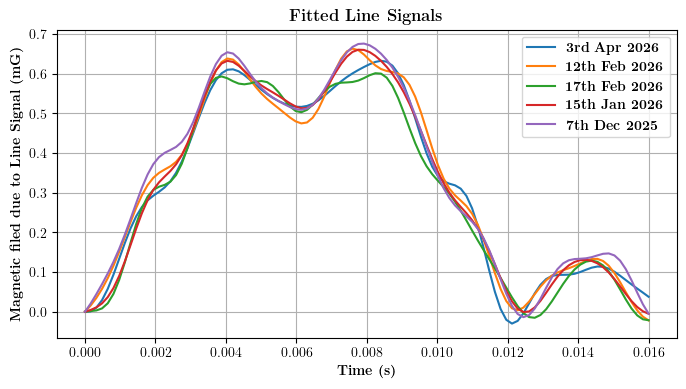

In [13]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Computer Modern']
rcParams['text.usetex'] = True
rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

plt.figure(figsize = (8,4))
times = np.linspace(0, 16000e-6, 100)
plt.plot(times, B_line_mG(times, param_file = 'line_signal_fit_params_20260403.txt') - B_line_mG(0, param_file = 'line_signal_fit_params_20260403.txt'), label = r'\textbf{3rd Apr 2026}')
plt.plot(times, B_line_mG(times, param_file = 'Z:\Lab Data\Line_signal_fitted_params\line_signal_fit_params_20260212.txt') - B_line_mG(0, param_file = 'Z:\Lab Data\Line_signal_fitted_params\line_signal_fit_params_20260212.txt'), label = r'\textbf{12th Feb 2026}')
plt.plot(times, B_line_mG(times) - B_line_mG(0), label = r'\textbf{17th Feb 2026}')
plt.plot(times, B_line_mG(times, param_file = 'line_signal_fit_params_20260115.txt') - B_line_mG(0, param_file = 'line_signal_fit_params_20260115.txt'), label = r'\textbf{15th Jan 2026}')
plt.plot(times, B_line_mG(times, param_file = 'line_signal_fit_params_20251207.txt') - B_line_mG(0, param_file = 'line_signal_fit_params_20251207.txt'), label = r'\textbf{7th Dec 2025}')
plt.legend()
plt.xlabel(r'\textbf{Time (s)}')
plt.ylabel(r'\textbf{Magnetic filed due to Line Signal (mG)}')
plt.title(r'\textbf{Fitted Line Signals}')
plt.grid()
plt.show()